In [2]:
# Business Problem

Healthcare organizations invest heavily in:
- doctor engagement
- patient retention
- digital consultations
- marketing campaigns

However, they struggle to identify:
Which operational factors drive hospital revenue growth?

This project aims to build a Machine Learning model capable of predicting Monthly Sales using hospital 
operational and patient engagement metrics.

In [ ]:
# Project Objective

The objective of this project is to:

- Analyze healthcare operational data
- Identify key business drivers
- Handle missing and inconsistent data
- Perform statistical analysis
- Build predictive ML models
- Compare model performance
- Generate business insights for strategic decision-making

,Hospital_ID,Region,Hospital_Beds,Marketing_Spend,Doctor_Visits,Patient_Count,Avg_Patient_Age,Treatment_Success_Rate,SMS_Reminder_Sent,Hospital_Rating,Monthly_Sales
0,H001,West,86,16130.0,674.0,854,41,0.592719,0,4.579658,129044.719456
1,H002,Central,329,92508.0,916.0,1415,61,0.932002,1,4.174007,341475.133652
2,H003,East,398,65566.0,302.0,893,49,0.971044,1,2.674829,252708.343050
3,H004,Central,351,71703.0,741.0,1934,62,0.728080,0,4.100421,288029.159023
4,H005,Central,230,32192.0,NaN,1406,36,0.930745,0,3.177869,136966.904548


Missing Values Before Cleaning:
Hospital_ID                0
Region                     0
Hospital_Beds              0
Marketing_Spend           15
Doctor_Visits              9
Patient_Count              0
Avg_Patient_Age            0
Treatment_Success_Rate     0
SMS_Reminder_Sent          0
Hospital_Rating           12
Monthly_Sales              0
dtype: int64
Training Data Shape: (236, 9)
Testing Data Shape: (59, 9)


,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.602,49119.14,65726.49
1,Random Forest,0.560,53937.75,69070.15


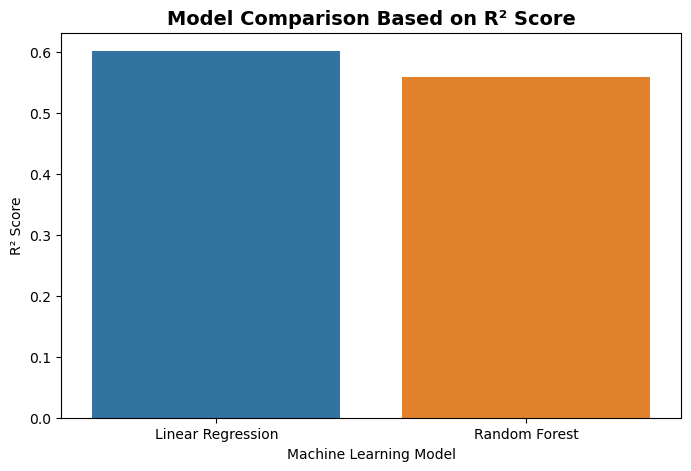

,Feature,Importance
2,Marketing_Spend,0.653156
4,Patient_Count,0.076946
3,Doctor_Visits,0.072969
8,Hospital_Rating,0.055157
6,Treatment_Success_Rate,0.040530
1,Hospital_Beds,0.039441
5,Avg_Patient_Age,0.038916
0,Region,0.017209
7,SMS_Reminder_Sent,0.005677


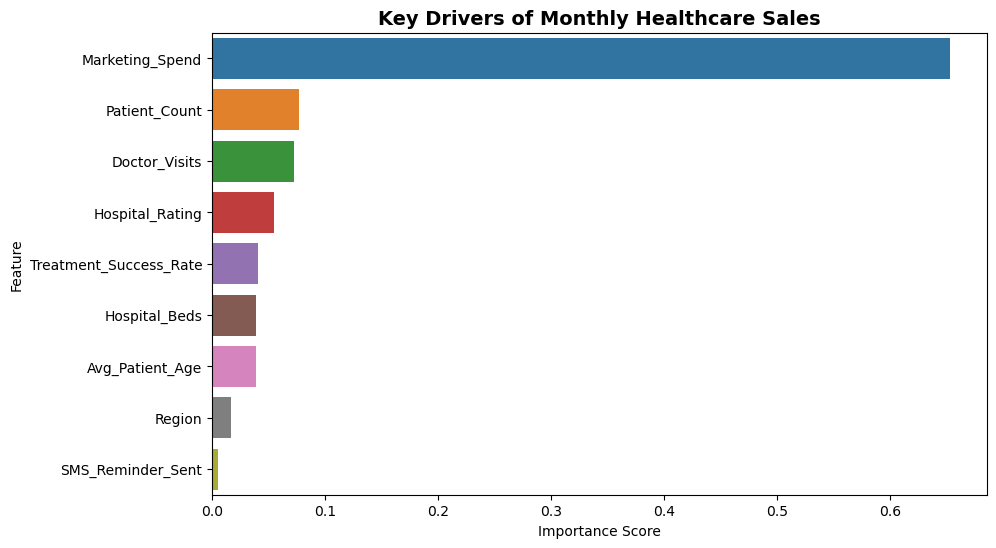

In [38]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv('dataset_1_healthcare_sales_cleaned (1).csv')

# Display first rows
display(df.head())

# Check missing values
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

# Handle missing values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

imputer = SimpleImputer(strategy='mean')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Encode categorical column
encoder = LabelEncoder()
df['Region'] = encoder.fit_transform(df['Region'])

# Create X and y
X = df.drop(['Hospital_ID', 'Monthly_Sales'], axis=1)
y = df['Monthly_Sales']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluation
lr_r2 = r2_score(y_test, y_pred_lr)
rf_r2 = r2_score(y_test, y_pred_rf)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Results table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [round(lr_r2, 3), round(rf_r2, 3)],
    'MAE': [round(lr_mae, 2), round(rf_mae, 2)],
    'RMSE': [round(lr_rmse, 2), round(rf_rmse, 2)]
})

display(results)

# Model comparison chart
plt.figure(figsize=(8,5))
sns.barplot(data=results, x='Model', y='R2 Score')
plt.title('Model Comparison Based on R² Score', fontsize=14, fontweight='bold')
plt.xlabel('Machine Learning Model')
plt.ylabel('R² Score')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(feature_importance)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Key Drivers of Monthly Healthcare Sales', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

,Actual Sales,Predicted Sales
273,287583.938391,267360.515518
155,246768.394765,115631.197597
84,52802.048168,106143.793215
82,154718.478278,104612.012650
261,324071.007176,225478.354159


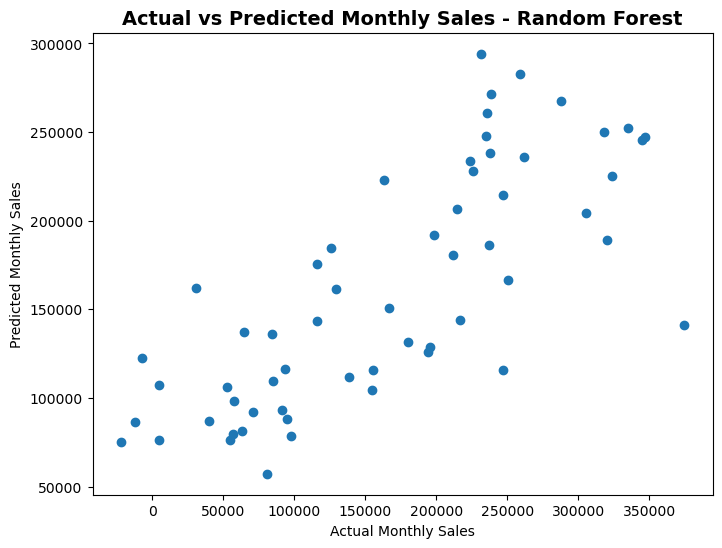

In [39]:
prediction_df = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred_rf
})

display(prediction_df.head())

plt.figure(figsize=(8,6))
plt.scatter(prediction_df['Actual Sales'], prediction_df['Predicted Sales'])
plt.xlabel('Actual Monthly Sales')
plt.ylabel('Predicted Monthly Sales')
plt.title('Actual vs Predicted Monthly Sales - Random Forest', fontsize=14, fontweight='bold')
plt.show()

In [40]:
prediction_df['Error'] = prediction_df['Actual Sales'] - prediction_df['Predicted Sales']
prediction_df['Absolute Error'] = abs(prediction_df['Error'])

display(prediction_df.head())

,Actual Sales,Predicted Sales,Error,Absolute Error
273,287583.938391,267360.515518,20223.422873,20223.422873
155,246768.394765,115631.197597,131137.197168,131137.197168
84,52802.048168,106143.793215,-53341.745047,53341.745047
82,154718.478278,104612.012650,50106.465628,50106.465628
261,324071.007176,225478.354159,98592.653018,98592.653018


In [41]:
top_errors = prediction_df.sort_values(by='Absolute Error', ascending=False).head(10)

display(top_errors)

,Actual Sales,Predicted Sales,Error,Absolute Error
228,374698.945067,141446.279442,233252.665626,233252.665626
245,30400.971758,162286.915984,-131885.944226,131885.944226
24,320457.878829,189062.364830,131395.513999,131395.513999
155,246768.394765,115631.197597,131137.197168,131137.197168
119,-7144.151754,122746.654722,-129890.806475,129890.806475
281,4558.344880,107079.509960,-102521.165080,102521.165080
113,305165.124885,204444.535510,100720.589374,100720.589374
193,346716.428056,247017.424629,99699.003427,99699.003427
226,344910.111037,245703.571133,99206.539903,99206.539903
111,-12487.129710,86402.489272,-98889.618982,98889.618982


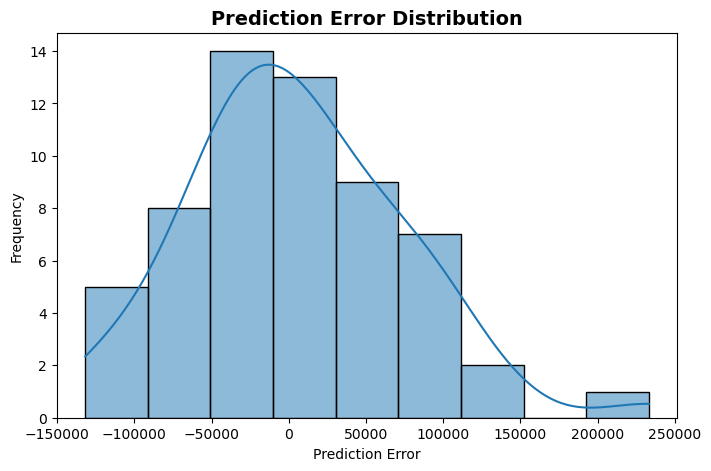

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(prediction_df['Error'], kde=True)
plt.title('Prediction Error Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.show()

In [ ]:
### Prediction Error Analysis

The error analysis shows the difference between actual and predicted monthly sales.  
Lower error values indicate stronger model performance.

This step helps identify hospitals where the model prediction deviated significantly, which can be 
useful for further business investigation.